<a href="https://www.kaggle.com/code/sonawanelalitsunil/pixar-films-a-box-office-and-ratings-analysis-ml?scriptVersionId=227320947" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pixar-films/pixar_films new.csv


## Title: "Pixar Films: A Box Office and Ratings Analysis"

## Description:
##### This analysis explores the financial and critical performance of Pixar films by examining key metrics such as budget, box office revenue, and audience ratings. Through detailed visualizations, we uncover trends in Pixar's success over time, the impact of critic and audience scores on box office performance, and how different factors—such as runtime, film rating, and release year—correlate with earnings. By applying machine learning models, we also predict box office performance based on historical data, providing insights into what makes a Pixar film a blockbuster.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/pixar-films/pixar_films new.csv')

In [3]:
df.head()

,ID,film,film_rating,cinema_score,release_date,run_time,budget,box_office_us_canada,box_office_other,box_office_worldwide,rotten_tomatoes_score,rotten_tomatoes_counts,metacritic_score,metacritic_counts,imdb_score,imdb_counts
0,1,Toy Story,G,A,1995-11-22,81,30000000,223225679,171210907,394436586,100,96,95,26,8.3,1089101
1,2,A Bug's Life,G,A,1998-11-25,95,120000000,162798565,200460294,363258859,92,91,78,23,7.2,319596
2,3,Toy Story 2,G,A+,1999-11-24,92,90000000,245852179,265506097,511358276,100,172,88,34,7.9,630573
3,4,"Monsters, Inc.",G,A+,2001-11-02,92,115000000,255873250,272900000,528773250,96,199,79,35,8.1,1000657
4,5,Finding Nemo,G,A+,2003-05-30,100,94000000,339714978,531300000,871014978,99,270,90,38,8.2,1132877


In [4]:
df.tail()

,ID,film,film_rating,cinema_score,release_date,run_time,budget,box_office_us_canada,box_office_other,box_office_worldwide,rotten_tomatoes_score,rotten_tomatoes_counts,metacritic_score,metacritic_counts,imdb_score,imdb_counts
23,24,Luca,PG,NaN,2021-06-18,95,0,1324302,49788012,51112314,91,303,71,52,7.4,202404
24,25,Turning Red,PG,NaN,2022-03-11,100,175000000,1399001,20414357,21813358,95,289,83,52,7.0,158649
25,26,Lightyear,PG,A-,2022-06-17,105,200000000,118307188,108118232,226425420,74,319,60,57,6.1,127045
26,27,Elemental,PG,A,2023-06-16,101,200000000,154426697,342017611,496444308,73,262,58,45,7.0,140174
27,28,Inside Out 2,PG,A,2024-06-14,96,200000000,652980194,1045050771,1698030965,90,313,73,59,7.6,168090


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      28 non-null     int64  
 1   film                    28 non-null     object 
 2   film_rating             28 non-null     object 
 3   cinema_score            25 non-null     object 
 4   release_date            28 non-null     object 
 5   run_time                28 non-null     int64  
 6   budget                  28 non-null     int64  
 7   box_office_us_canada    28 non-null     int64  
 8   box_office_other        28 non-null     int64  
 9   box_office_worldwide    28 non-null     int64  
 10  rotten_tomatoes_score   28 non-null     int64  
 11  rotten_tomatoes_counts  28 non-null     int64  
 12  metacritic_score        28 non-null     int64  
 13  metacritic_counts       28 non-null     int64  
 14  imdb_score              28 non-null     floa

In [6]:
df.describe()

,ID,run_time,budget,box_office_us_canada,box_office_other,box_office_worldwide,rotten_tomatoes_score,rotten_tomatoes_counts,metacritic_score,metacritic_counts,imdb_score,imdb_counts
count,28.000000,28.000000,2.800000e+01,2.800000e+01,2.800000e+01,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000,2.800000e+01
mean,14.500000,100.392857,1.553929e+08,2.475444e+08,3.611199e+08,6.086643e+08,88.357143,273.821429,78.142857,43.464286,7.542857,5.256077e+05
std,8.225975,8.047725,5.382092e+07,1.631609e+08,2.300110e+08,3.826497e+08,13.447330,84.248773,12.408821,9.558716,0.658522,3.688713e+05
min,1.000000,81.000000,0.000000e+00,9.461540e+05,2.041436e+07,2.181336e+07,40.000000,91.000000,57.000000,23.000000,6.100000,1.270450e+05
25%,7.750000,95.000000,1.200000e+08,1.540453e+08,2.069555e+08,3.787627e+08,79.750000,220.000000,68.250000,37.000000,7.175000,1.955322e+05
50%,14.500000,100.000000,1.750000e+08,2.305457e+08,3.218588e+08,5.338782e+08,94.500000,266.000000,79.500000,41.000000,7.550000,3.958430e+05
75%,21.250000,104.250000,2.000000e+08,3.046819e+08,5.086871e+08,8.253837e+08,97.000000,324.000000,88.500000,52.000000,8.100000,8.385082e+05
max,28.000000,118.000000,2.000000e+08,6.529802e+08,1.045051e+09,1.698031e+09,100.000000,459.000000,96.000000,59.000000,8.400000,1.226415e+06


In [7]:
df.isnull().sum()

ID                        0
film                      0
film_rating               0
cinema_score              3
release_date              0
run_time                  0
budget                    0
box_office_us_canada      0
box_office_other          0
box_office_worldwide      0
rotten_tomatoes_score     0
rotten_tomatoes_counts    0
metacritic_score          0
metacritic_counts         0
imdb_score                0
imdb_counts               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

ID                          int64
film                       object
film_rating                object
cinema_score               object
release_date               object
run_time                    int64
budget                      int64
box_office_us_canada        int64
box_office_other            int64
box_office_worldwide        int64
rotten_tomatoes_score       int64
rotten_tomatoes_counts      int64
metacritic_score            int64
metacritic_counts           int64
imdb_score                float64
imdb_counts                 int64
dtype: object

In [10]:
df.shape

(28, 16)

In [11]:
df.columns

Index(['ID', 'film', 'film_rating', 'cinema_score', 'release_date', 'run_time',
       'budget', 'box_office_us_canada', 'box_office_other',
       'box_office_worldwide', 'rotten_tomatoes_score',
       'rotten_tomatoes_counts', 'metacritic_score', 'metacritic_counts',
       'imdb_score', 'imdb_counts'],
      dtype='object')

## Data visualizations 

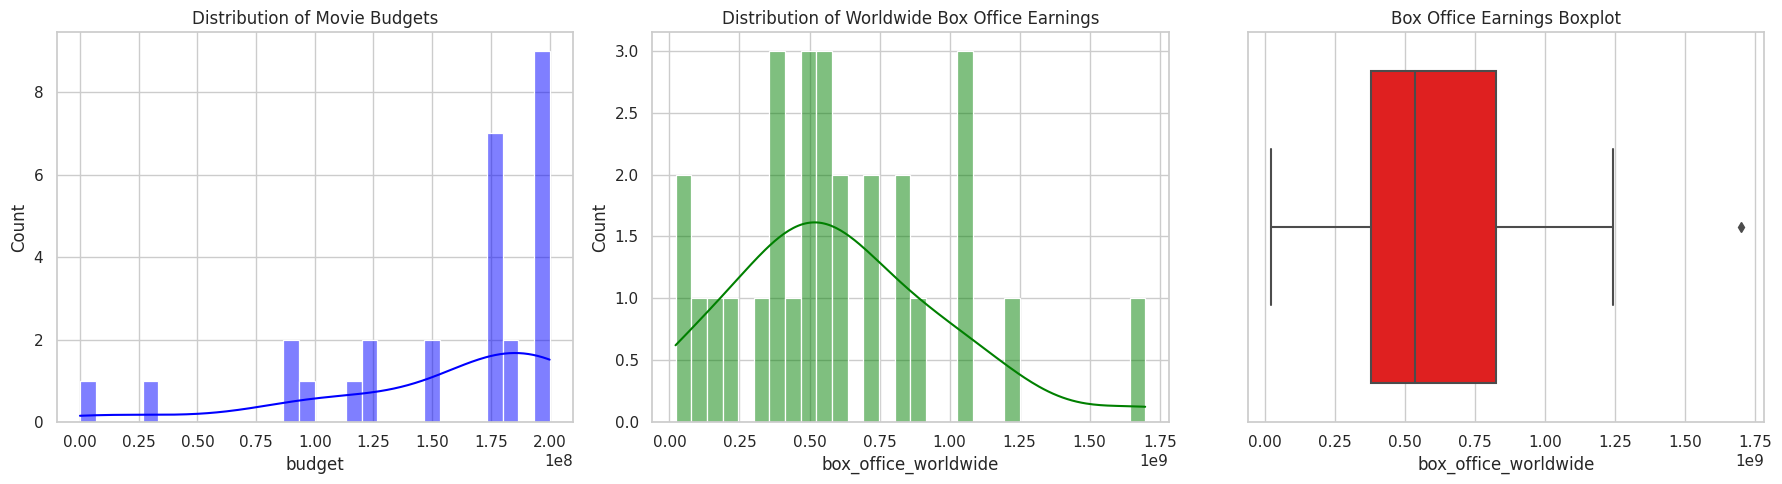

In [12]:
sns.set_theme(style="whitegrid")

# 1. Distribution of Budget and Box Office Earnings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['budget'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title("Distribution of Movie Budgets")
sns.histplot(df['box_office_worldwide'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title("Distribution of Worldwide Box Office Earnings")
sns.boxplot(x=df['box_office_worldwide'], ax=axes[2], color='red')
axes[2].set_title("Box Office Earnings Boxplot")
plt.tight_layout()
plt.show()

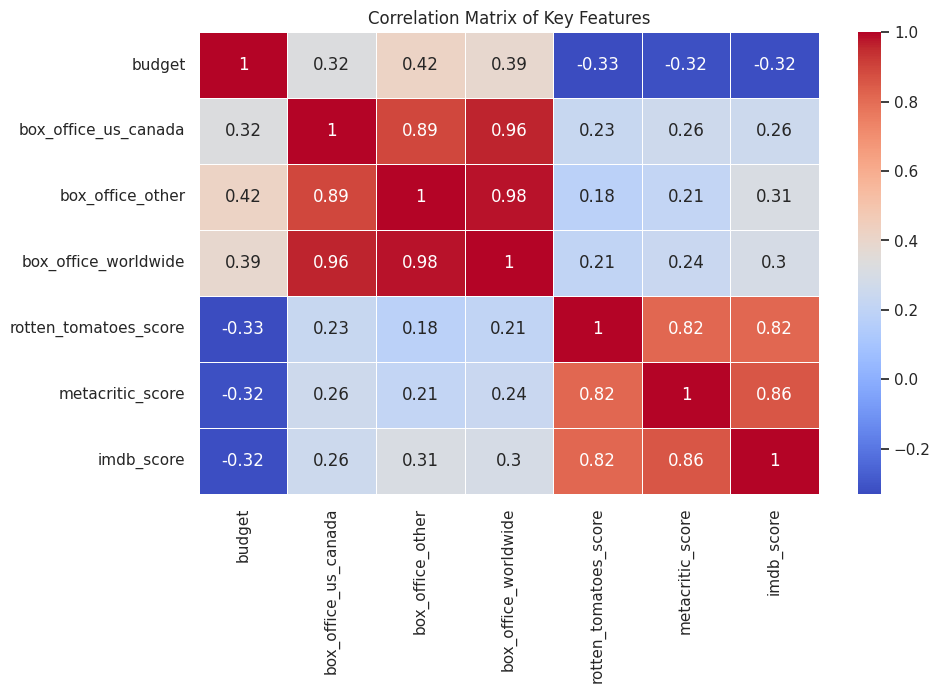

In [13]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
corr_matrix = df[['budget', 'box_office_us_canada', 'box_office_other', 'box_office_worldwide',
                  'rotten_tomatoes_score', 'metacritic_score', 'imdb_score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Key Features")
plt.show()

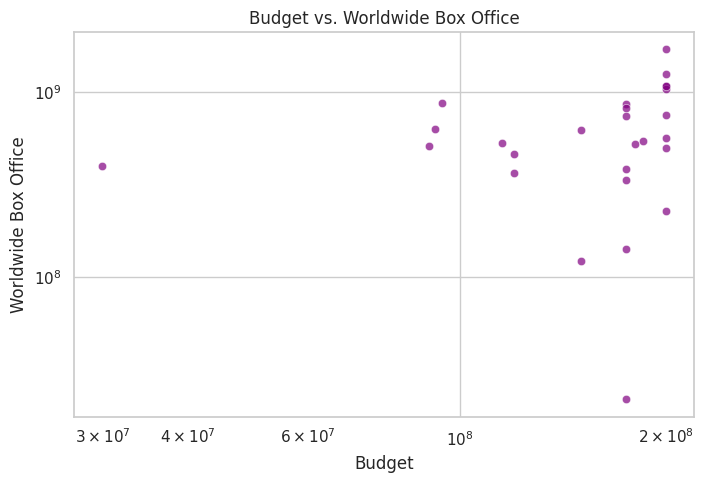

In [14]:
# 3. Budget vs. Worldwide Box Office
plt.figure(figsize=(8, 5))
sns.scatterplot(x='budget', y='box_office_worldwide', data=df, alpha=0.7, color='purple')
plt.xlabel("Budget")
plt.ylabel("Worldwide Box Office")
plt.title("Budget vs. Worldwide Box Office")
plt.xscale("log")  # Log scale for better visualization
plt.yscale("log")
plt.show()

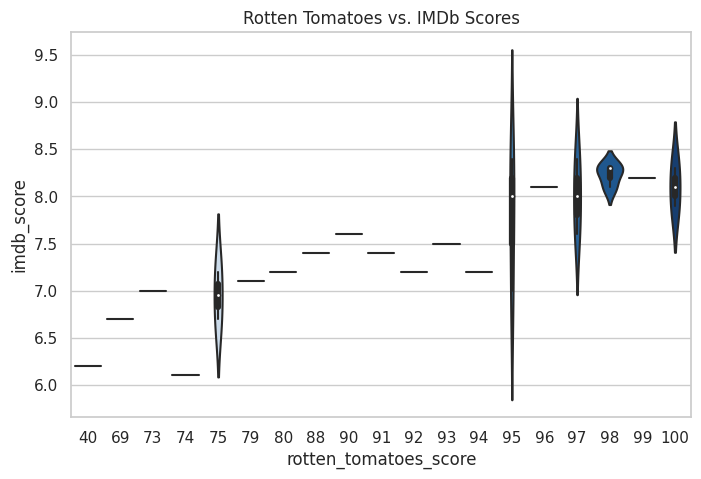

In [15]:
# 4. Ratings Comparison
plt.figure(figsize=(8, 5))
sns.violinplot(x="rotten_tomatoes_score", y="imdb_score", data=df, palette="Blues")
plt.title("Rotten Tomatoes vs. IMDb Scores")
plt.show()

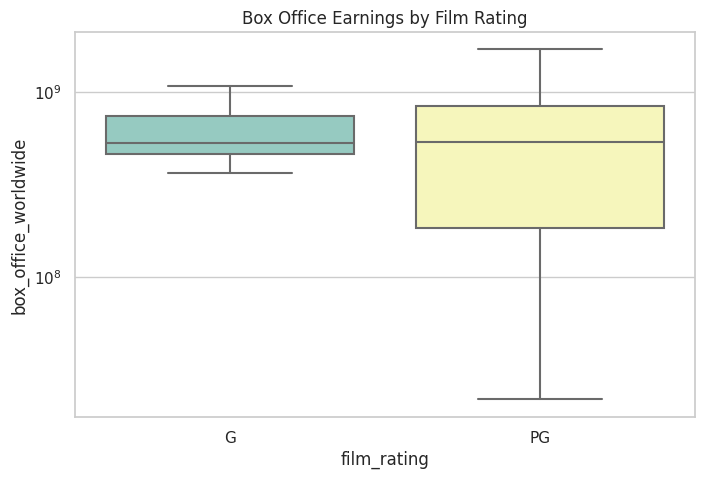

In [16]:
# 5. Box Office by Film Rating
plt.figure(figsize=(8, 5))
sns.boxplot(x='film_rating', y='box_office_worldwide', data=df, palette="Set3")
plt.yscale("log")  # Handle outliers better
plt.title("Box Office Earnings by Film Rating")
plt.show()

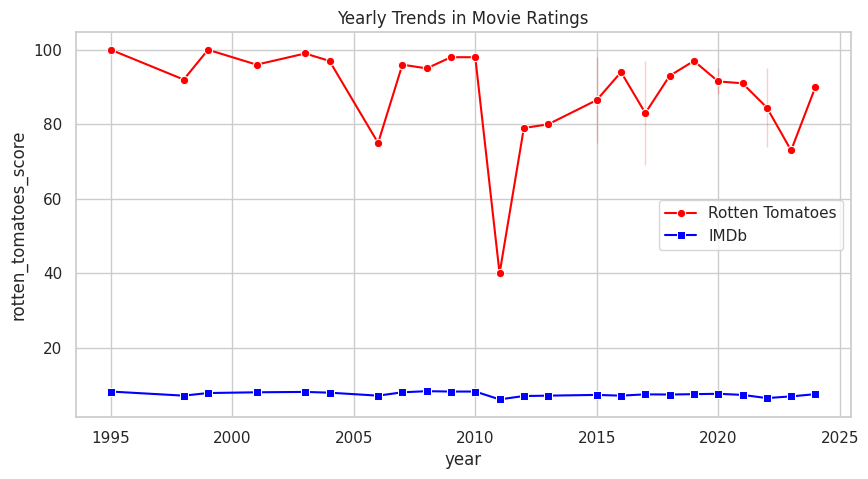

In [17]:
# 6. Yearly Trends in Ratings
plt.figure(figsize=(10, 5))
df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year
sns.lineplot(x='year', y='rotten_tomatoes_score', data=df, label='Rotten Tomatoes', marker='o', color='red')
sns.lineplot(x='year', y='imdb_score', data=df, label='IMDb', marker='s', color='blue')
plt.title("Yearly Trends in Movie Ratings")
plt.legend()
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score

In [19]:
sns.set_theme(style="whitegrid")

# Encode categorical variables
label_encoders = {}
categorical_columns = ['film', 'film_rating']
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [20]:
# Feature selection
features = ['budget', 'run_time', 'film_rating', 'rotten_tomatoes_score', 'metacritic_score', 'imdb_score']
target = 'box_office_worldwide'

In [21]:
# Drop missing values
df = df.dropna(subset=features + [target])

# Split dataset into train and test sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR()
}

In [24]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = r2_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = accuracy


In [25]:
# Print results
print("Model Performance (R² Score in %):")
for model, score in results.items():
    print(f"{model}: {score:.2f}%")

Model Performance (R² Score in %):
Linear Regression: -225.85%
Random Forest: -37.98%
Support Vector Regressor: -68.72%


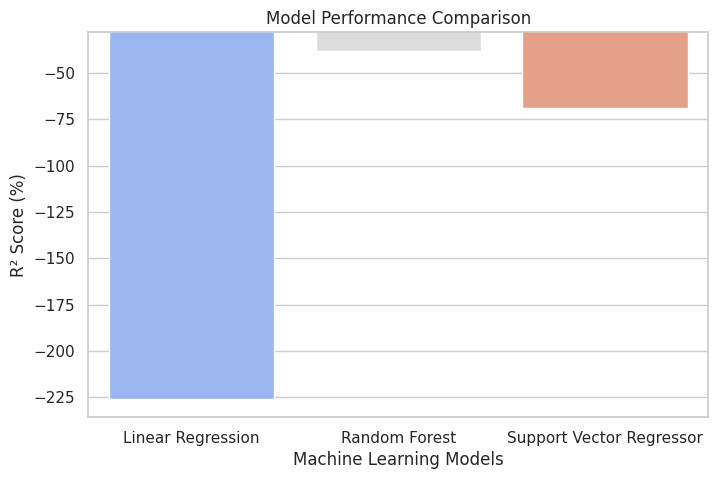

In [26]:
# Plot model accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.ylabel("R² Score (%)")
plt.xlabel("Machine Learning Models")
plt.title("Model Performance Comparison")
plt.ylim(min(results.values()) - 10, max(results.values()) + 10)
plt.show()

## Thank you!!!!...pls upvotes!!!!!